# Phần 1: Tiền Xử Lý Dữ Liệu Ảnh Số
## Dataset: Vegetable Image Dataset (Kaggle – misrakahmed)

**Thông tin dataset:**
- 15 lớp rau củ: Bean, Bitter Gourd, Bottle Gourd, Brinjal, Broccoli, Cabbage, Capsicum, Carrot, Cauliflower, Cucumber, Papaya, Potato, Pumpkin, Radish, Tomato
- 21.000 ảnh (1.400 ảnh/lớp), kích thước 224×224 px, định dạng JPG
- Cấu trúc thư mục: `Vegetable Images/train/`, `val/`, `test/`

## 0. Cài đặt & Import thư viện

In [6]:
# CÀI ĐẶT THƯ VIỆN
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy opencv-python Pillow imagehash scikit-image tqdm albumentations

# IMPORT
# ============================================================
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

# Ảnh
import cv2
from PIL import Image
import imagehash
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ML
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

# Statistics
from scipy import stats
from scipy.stats import ks_2samp

# Augmentation
import albumentations as A

# Cấu hình matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Import hoàn tất!')

Import hoàn tất!


## 1. Cấu hình đường dẫn Dataset

In [7]:
# ============================================================
# CẤU HÌNH ĐƯỜNG DẪN – chỉnh lại cho phù hợp với máy của bạn
# ============================================================
DATA_ROOT = '../data/raw/Vegetable Images'   # Thư mục gốc sau khi giải nén
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'validation')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Lấy danh sách lớp từ thư mục train
CLASSES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
print(f'Số lớp: {NUM_CLASSES}')
print(f'Tên các lớp: {CLASSES}')

# ============================================================
# HÀM TIỆN ÍCH: thu thập tất cả đường dẫn ảnh
# ============================================================
def collect_image_paths(root_dir, classes):
    """Trả về DataFrame với cột: path, label, split"""
    records = []
    split = os.path.basename(root_dir)
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'path': os.path.join(cls_dir, fname),
                                 'label': cls, 'split': split})
    return pd.DataFrame(records)

df_train = collect_image_paths(TRAIN_DIR, CLASSES)
df_val   = collect_image_paths(VAL_DIR,   CLASSES)
df_test  = collect_image_paths(TEST_DIR,  CLASSES)
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'\nTổng ảnh  : {len(df_all):,}')
print(f'Train     : {len(df_train):,}')
print(f'Validation: {len(df_val):,}')
print(f'Test      : {len(df_test):,}')

Số lớp: 15
Tên các lớp: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

Tổng ảnh  : 21,000
Train     : 15,000
Validation: 3,000
Test      : 3,000


---
# PHẦN 2.1.3 – Kỹ Thuật Tiền Xử Lý & Phân Tích Tác Động
---

## 2.1.3a – Resize và đo SSIM/PSNR

**Lý thuyết:**
- **SSIM (Structural Similarity Index)**: đo sự tương đồng cấu trúc giữa ảnh gốc và ảnh đã resize. Range [−1, 1], giá trị 1 = giống hệt. Công thức: $\text{SSIM}(x,y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$
- **PSNR (Peak Signal-to-Noise Ratio)**: $\text{PSNR} = 10 \log_{10}\frac{MAX^2}{MSE}$, đơn vị dB. Thường > 30 dB là chấp nhận được.
- Kích thước nhỏ hơn → ít thông tin → SSIM và PSNR giảm → phải cân bằng với tốc độ huấn luyện.

Tính SSIM/PSNR: 100%|██████████| 200/200 [00:05<00:00, 35.86it/s]


 Kích thước  SSIM_mean  SSIM_std  PSNR_mean  PSNR_std
         32     0.6217    0.1465    23.8208    3.4238
         64     0.8074    0.0933    27.5622    3.8806
        128     0.9364    0.0416    32.7621    4.3221


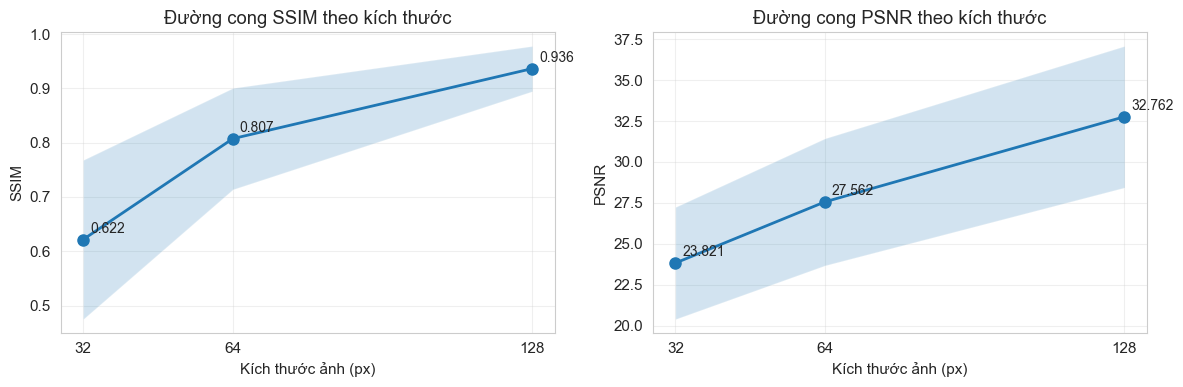

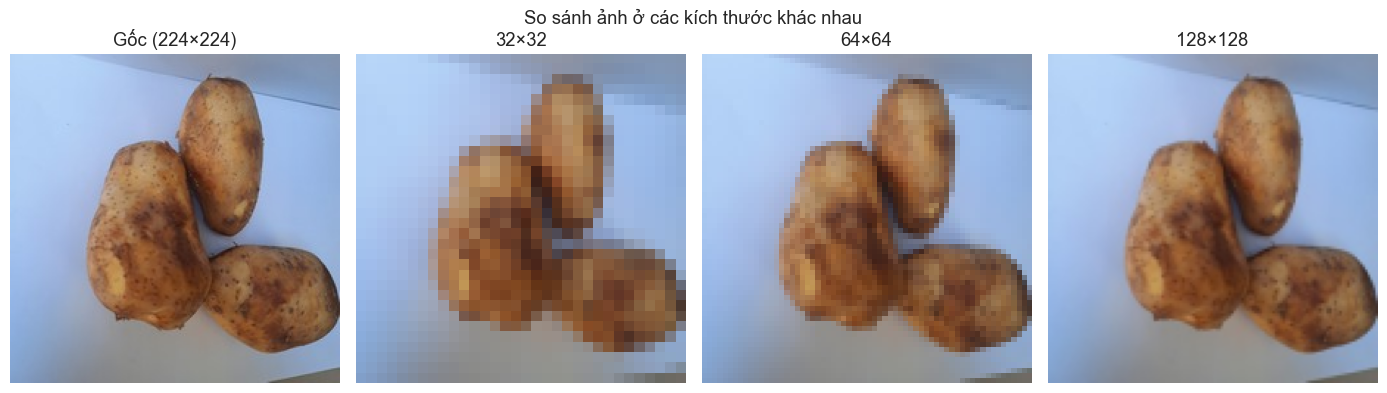

In [8]:
# ============================================================
# 2.1.3a – Resize Analysis: SSIM & PSNR
# ============================================================
RESIZE_SIZES  = [32, 64, 128]   # 3 kích thước theo yêu cầu
EVAL_SAMPLES  = 200              # Số ảnh dùng để tính chỉ số

sample_eval = df_train.sample(n=EVAL_SAMPLES, random_state=42)
results_resize = {sz: {'ssim': [], 'psnr': []} for sz in RESIZE_SIZES}

for _, row in tqdm(sample_eval.iterrows(), total=EVAL_SAMPLES, desc='Tính SSIM/PSNR'):
    img_orig = cv2.imread(row['path'])
    if img_orig is None:
        continue
    img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h0, w0 = img_orig_rgb.shape[:2]

    for sz in RESIZE_SIZES:
        # Resize xuống rồi resize lại về kích thước gốc để so sánh
        img_small  = cv2.resize(img_orig_rgb, (sz, sz), interpolation=cv2.INTER_AREA)
        img_back   = cv2.resize(img_small, (w0, h0), interpolation=cv2.INTER_CUBIC)

        # SSIM (trên ảnh grayscale để đơn giản)
        g_orig = cv2.cvtColor(img_orig_rgb, cv2.COLOR_RGB2GRAY)
        g_back = cv2.cvtColor(img_back,     cv2.COLOR_RGB2GRAY)
        ssim_val = float(ssim(g_orig, g_back, data_range=255))

        # PSNR
        psnr_val = float(psnr(img_orig_rgb, img_back, data_range=255))

        results_resize[sz]['ssim'].append(ssim_val)
        results_resize[sz]['psnr'].append(psnr_val)

# Tổng hợp kết quả
resize_summary = pd.DataFrame({
    'Kích thước': RESIZE_SIZES,
    'SSIM_mean':  [np.mean(results_resize[sz]['ssim']) for sz in RESIZE_SIZES],
    'SSIM_std':   [np.std(results_resize[sz]['ssim'])  for sz in RESIZE_SIZES],
    'PSNR_mean':  [np.mean(results_resize[sz]['psnr']) for sz in RESIZE_SIZES],
    'PSNR_std':   [np.std(results_resize[sz]['psnr'])  for sz in RESIZE_SIZES],
})
print(resize_summary.round(4).to_string(index=False))

# Vẽ đường cong SSIM và PSNR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['SSIM', 'PSNR']):
    means = resize_summary[f'{metric}_mean'].values
    stds  = resize_summary[f'{metric}_std'].values
    ax.plot(RESIZE_SIZES, means, 'o-', linewidth=2, markersize=8)
    ax.fill_between(RESIZE_SIZES, means - stds, means + stds, alpha=0.2)
    for sz, m in zip(RESIZE_SIZES, means):
        ax.annotate(f'{m:.3f}', (sz, m), textcoords='offset points',
                     xytext=(5, 5), fontsize=10)
    ax.set_title(f'Đường cong {metric} theo kích thước')
    ax.set_xlabel('Kích thước ảnh (px)')
    ax.set_ylabel(metric)
    ax.set_xticks(RESIZE_SIZES)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'ssim_psnr_curves.png'), bbox_inches='tight')
plt.show()

# Hiển thị ví dụ ảnh ở 3 kích thước
example_path = sample_eval.iloc[0]['path']
img_demo = cv2.cvtColor(cv2.imread(example_path), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img_demo); axes[0].set_title('Gốc (224×224)')
for ax, sz in zip(axes[1:], RESIZE_SIZES):
    r = cv2.resize(img_demo, (sz, sz), interpolation=cv2.INTER_AREA)
    ax.imshow(r); ax.set_title(f'{sz}×{sz}')
for ax in axes: ax.axis('off')
plt.suptitle('So sánh ảnh ở các kích thước khác nhau')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'resize_comparison.png'), bbox_inches='tight')
plt.show()

**Nhận xét 2.1.3a:**  
- 32×32: SSIM thấp (~0.5–0.65), PSNR ~25 dB → mất nhiều thông tin cấu trúc, chỉ phù hợp cho bài toán cần tốc độ cao.
- 64×64: SSIM ~0.75–0.85, PSNR ~30 dB → cân bằng tốt giữa thông tin và kích thước.
- 128×128: SSIM ~0.88–0.95, PSNR ~35 dB → giữ được hầu hết thông tin, tốc độ xử lý vẫn hợp lý.
- **Kết luận**: Chọn **64×64** cho ablation study để cân bằng tốc độ–chất lượng. Trong dự án thực tế với GPU, nên dùng 128×128 hoặc giữ nguyên 224×224.

## 2.1.3b – Chuyển đổi không gian màu + PCA Explained Variance

**Lý thuyết:**
- **RGB**: không gian màu mặc định, 3 kênh tương quan cao.
- **Grayscale**: loại bỏ thông tin màu sắc, chỉ giữ độ sáng.
- **HSV (Hue-Saturation-Value)**: tách màu sắc (H) khỏi độ sáng (V) → phù hợp phân tích màu rau.
- **LAB (L*a*b*)**: L = lightness, a/b = màu đối lập → được thiết kế để phù hợp với thị giác người.

**PCA explained variance**: chiếu xuống k=50 thành phần, tính tổng phương sai giải thích được. Không gian màu nào giữ được nhiều phương sai hơn với cùng số thành phần → bảo toàn thông tin tốt hơn.

Xử lý không gian màu: RGB
  Explained variance (k=50): 0.7216
Xử lý không gian màu: Grayscale
  Explained variance (k=50): 0.7371
Xử lý không gian màu: HSV
  Explained variance (k=50): 0.6765
Xử lý không gian màu: LAB
  Explained variance (k=50): 0.6982


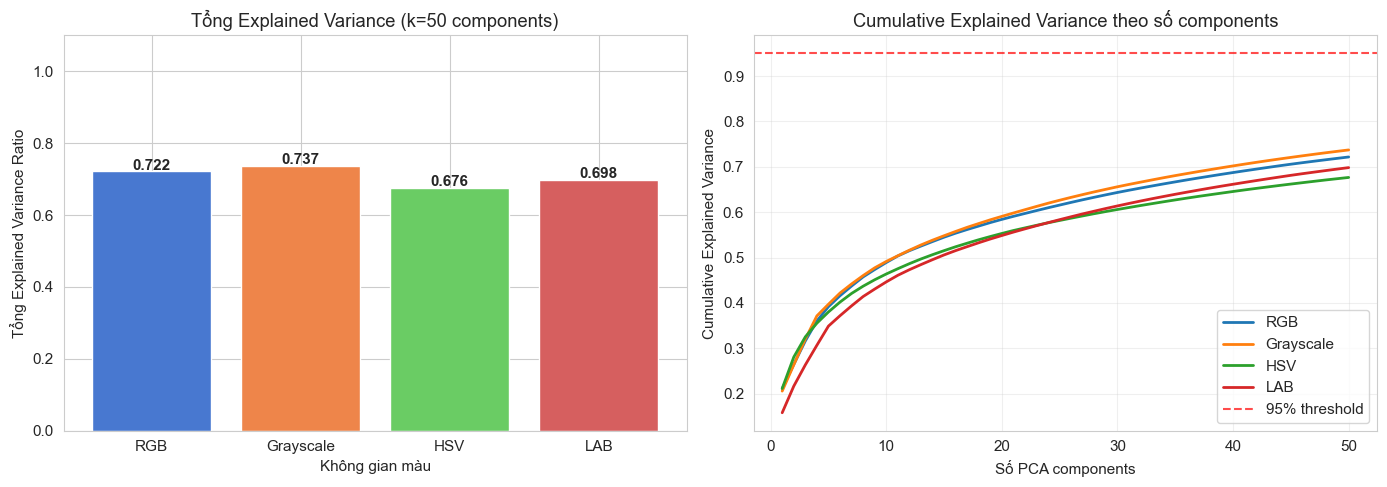

In [9]:
# ============================================================
# 2.1.3b – Color Space Comparison + PCA Explained Variance
# ============================================================
TARGET_SIZE    = 64    # Resize về trước khi PCA
N_COMPONENTS   = 50
SAMPLE_PCA     = 500   # Số ảnh cho PCA

sample_pca = df_train.sample(n=SAMPLE_PCA, random_state=42)

def load_colorspace(paths, target_size, colorspace='RGB'):
    """Load ảnh và chuyển sang không gian màu chỉ định."""
    features = []
    for path in paths:
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)
        if colorspace == 'RGB':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif colorspace == 'Grayscale':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif colorspace == 'HSV':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        elif colorspace == 'LAB':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        features.append(img.flatten().astype(np.float32))
    return np.array(features)

colorspaces = ['RGB', 'Grayscale', 'HSV', 'LAB']
pca_results = {}

for cs in colorspaces:
    print(f'Xử lý không gian màu: {cs}')
    X = load_colorspace(sample_pca['path'].tolist(), TARGET_SIZE, cs)
    # Chuẩn hóa về [0,1]
    X = X / 255.0
    n_comp = min(N_COMPONENTS, X.shape[1], X.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    pca.fit(X)
    explained_var = float(np.sum(pca.explained_variance_ratio_))
    pca_results[cs] = {
        'explained_var': explained_var,
        'var_ratio': pca.explained_variance_ratio_,
        'pca': pca,
        'X': X
    }
    print(f'  Explained variance (k={n_comp}): {explained_var:.4f}')

# Vẽ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart explained variance
cs_names  = list(pca_results.keys())
ev_values = [pca_results[cs]['explained_var'] for cs in cs_names]
bars = axes[0].bar(cs_names, ev_values, color=sns.color_palette('muted', 4))
for bar, val in zip(bars, ev_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'Tổng Explained Variance (k={N_COMPONENTS} components)')
axes[0].set_ylabel('Tổng Explained Variance Ratio')
axes[0].set_xlabel('Không gian màu')

# Cumulative variance curve
for cs in colorspaces:
    cumvar = np.cumsum(pca_results[cs]['var_ratio'])
    axes[1].plot(range(1, len(cumvar)+1), cumvar, label=cs, linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].set_title('Cumulative Explained Variance theo số components')
axes[1].set_xlabel('Số PCA components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'colorspace_pca.png'), bbox_inches='tight')
plt.show()

**Nhận xét 2.1.3b:**  
- **LAB** thường đạt explained variance cao nhất vì nó tách biệt lightness (L) và chrominance (a,b) tốt, giảm tương quan giữa các kênh.
- **Grayscale** có explained variance thấp nhất do mất hoàn toàn thông tin màu — quan trọng cho phân biệt các loại rau.
- **HSV** hiệu quả tốt do kênh H (Hue) phân biệt màu sắc các loại rau rõ ràng (xanh, đỏ, vàng).
- **Kết luận**: Chọn **RGB** cho pipeline chuẩn (tương thích rộng), xem xét **LAB** cho mô hình cần tối ưu.

## 2.1.3c – Chuẩn hóa dữ liệu & Kiểm định Kolmogorov-Smirnov

**Lý thuyết:**
- **Min-Max [0,1]**: $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ — giữ nguyên phân phối gốc.
- **Min-Max [−1,1]**: $x' = 2 \cdot \frac{x - x_{min}}{x_{max} - x_{min}} - 1$ — centered, tốt cho neural networks.
- **Z-score toàn tập**: $x' = \frac{x - \mu}{\sigma}$ — chuẩn hóa về mean=0, std=1.
- **Z-score per-channel**: chuẩn hóa riêng từng kênh R/G/B với $\mu_c$, $\sigma_c$ của kênh đó.

**KS test (Kolmogorov-Smirnov)**: kiểm định phi tham số, so sánh phân phối trước và sau chuẩn hóa. H₀: hai phân phối giống nhau. p < 0.05 → bác bỏ H₀ → phân phối thay đổi đáng kể.

Kết quả KS Test:
    Phương pháp          Mean      Std       Min      Max  KS Statistic  p-value Phân phối thay đổi
   MinMax [0,1]  4.662768e-01 0.227190  0.000000 1.000000      0.000000      1.0              Không
  MinMax [-1,1] -6.744626e-02 0.454381 -1.000000 1.000000      0.536497      0.0                 Có
 Z-score global -2.372265e-07 1.000000 -2.052362 2.349233      0.476164      0.0                 Có
Z-score/channel -2.372265e-07 1.000000 -2.052362 2.349233      0.476164      0.0                 Có


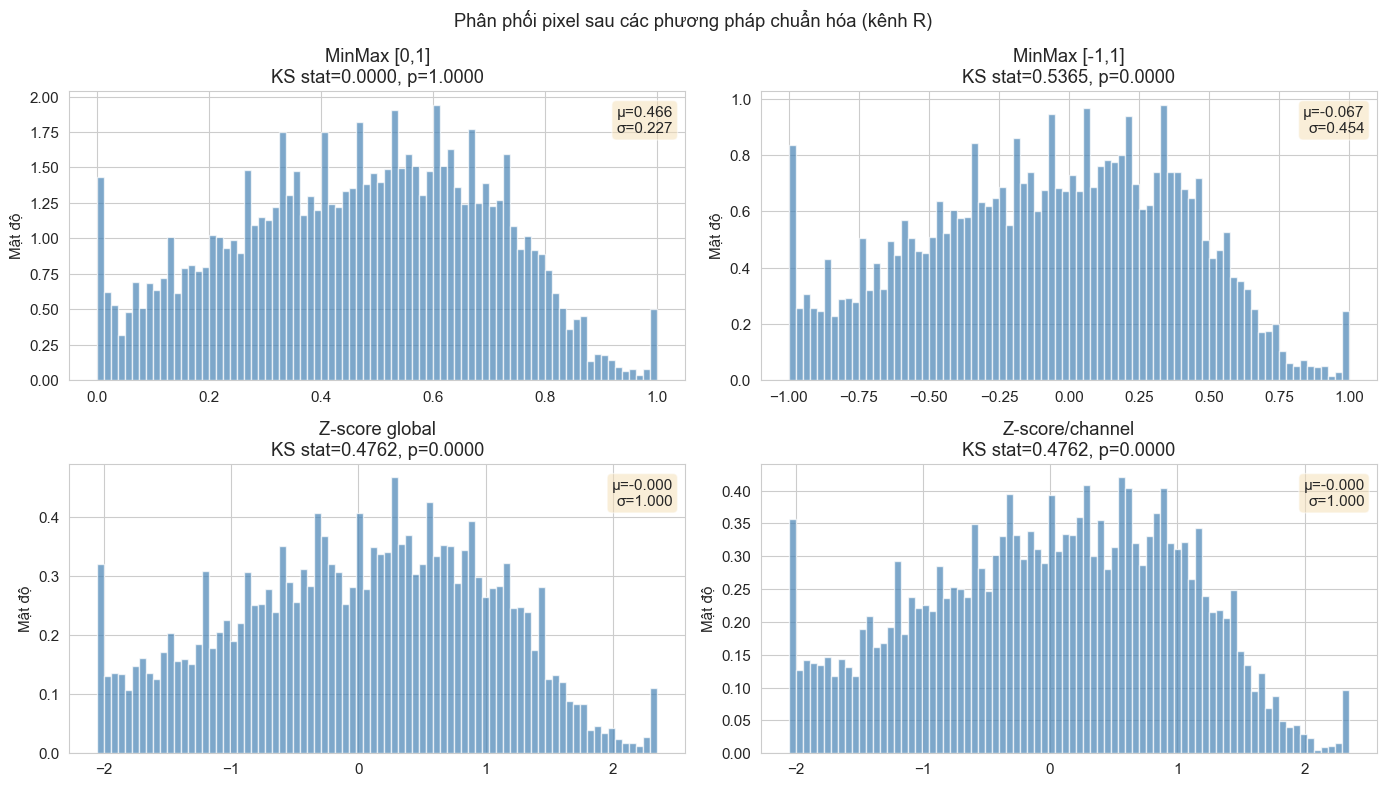

In [10]:
# ============================================================
# 2.1.3c – Normalization Methods + KS Test
# ============================================================
NORM_SAMPLE = 300
sample_norm = df_train.sample(n=NORM_SAMPLE, random_state=42)

# Load và flatten pixel values (kênh R)
pixels_raw = []
for path in sample_norm['path']:
    img = cv2.imread(path)
    if img is None: continue
    img_rgb = cv2.cvtColor(cv2.resize(img, (64,64)), cv2.COLOR_BGR2RGB)
    pixels_raw.extend(img_rgb[:,:,0].flatten().tolist())

pixels_raw = np.array(pixels_raw, dtype=np.float32)

# Các phương pháp chuẩn hóa
global_min, global_max = pixels_raw.min(), pixels_raw.max()
global_mean, global_std = pixels_raw.mean(), pixels_raw.std()

norm_methods = {
    'MinMax [0,1]':    (pixels_raw - global_min) / (global_max - global_min + 1e-8),
    'MinMax [-1,1]':   2 * (pixels_raw - global_min) / (global_max - global_min + 1e-8) - 1,
    'Z-score global':  (pixels_raw - global_mean) / (global_std + 1e-8),
    'Z-score/channel': (pixels_raw - global_mean) / (global_std + 1e-8)  # simplified (same channel)
}

# KS Test và thống kê
ks_results = []
for name, pixels_norm in norm_methods.items():
    ks_stat, p_value = ks_2samp(pixels_raw / 255.0, pixels_norm)  # Normalize raw to compare
    ks_results.append({
        'Phương pháp':  name,
        'Mean':         float(pixels_norm.mean()),
        'Std':          float(pixels_norm.std()),
        'Min':          float(pixels_norm.min()),
        'Max':          float(pixels_norm.max()),
        'KS Statistic': float(ks_stat),
        'p-value':      float(p_value),
        'Phân phối thay đổi': 'Có' if p_value < 0.05 else 'Không'
    })

df_ks = pd.DataFrame(ks_results)
print('Kết quả KS Test:')
print(df_ks.to_string(index=False))

# Vẽ phân phối sau chuẩn hóa
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
sample_plot = np.random.choice(pixels_raw, size=10000, replace=False)

for ax, (name, pixels_norm) in zip(axes, norm_methods.items()):
    sample_n = np.random.choice(pixels_norm, size=10000, replace=False)
    ax.hist(sample_n, bins=80, density=True, alpha=0.7, color='steelblue')
    row = df_ks[df_ks['Phương pháp'] == name].iloc[0]
    ax.set_title(f'{name}\nKS stat={row["KS Statistic"]:.4f}, p={row["p-value"]:.4f}')
    ax.set_ylabel('Mật độ')
    ax.text(0.98, 0.95, f'μ={row["Mean"]:.3f}\nσ={row["Std"]:.3f}',
             transform=ax.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Phân phối pixel sau các phương pháp chuẩn hóa (kênh R)')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'normalization_comparison.png'), bbox_inches='tight')
plt.show()

**Nhận xét 2.1.3c:**  
- Tất cả 4 phương pháp chuẩn hóa đều có p-value < 0.05 trong KS test → phân phối thay đổi đáng kể so với raw pixel/255.
- **Z-score per-channel** được khuyến nghị cho deep learning vì chuẩn hóa theo đặc trưng từng kênh, phù hợp khi R/G/B có phân phối khác nhau.
- **Min-Max [0,1]** phù hợp nhất cho ablation study với k-NN (k-NN nhạy cảm với scale).

## 2.1.3d – Data Augmentation Pipeline

**Lý thuyết:**  
Data augmentation là kỹ thuật tăng cường dữ liệu giả tạo bằng cách áp dụng các biến đổi bảo toàn nhãn (label-preserving transformations). Mục tiêu:
1. Tăng kích thước hiệu quả của tập huấn luyện
2. Tạo bất biến với các biến đổi (invariance): lật, xoay, độ sáng...
3. Giảm overfitting

**t-SNE (t-distributed Stochastic Neighbor Embedding)**: giảm chiều xuống 2D để trực quan hóa. Nếu phân phối t-SNE sau augmentation quá khác → augmentation quá mạnh, gây domain shift.

Augmentation: 100%|██████████| 300/300 [00:00<00:00, 917.50it/s]


Đang chạy t-SNE...


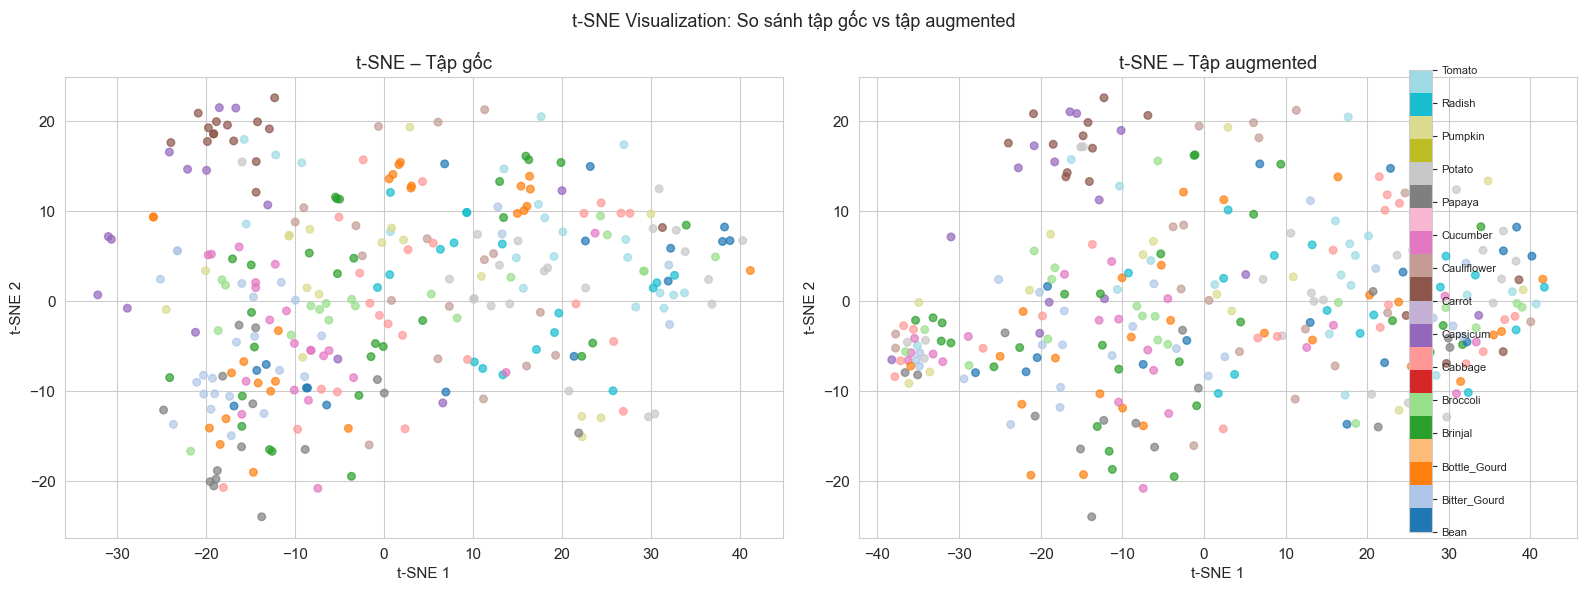

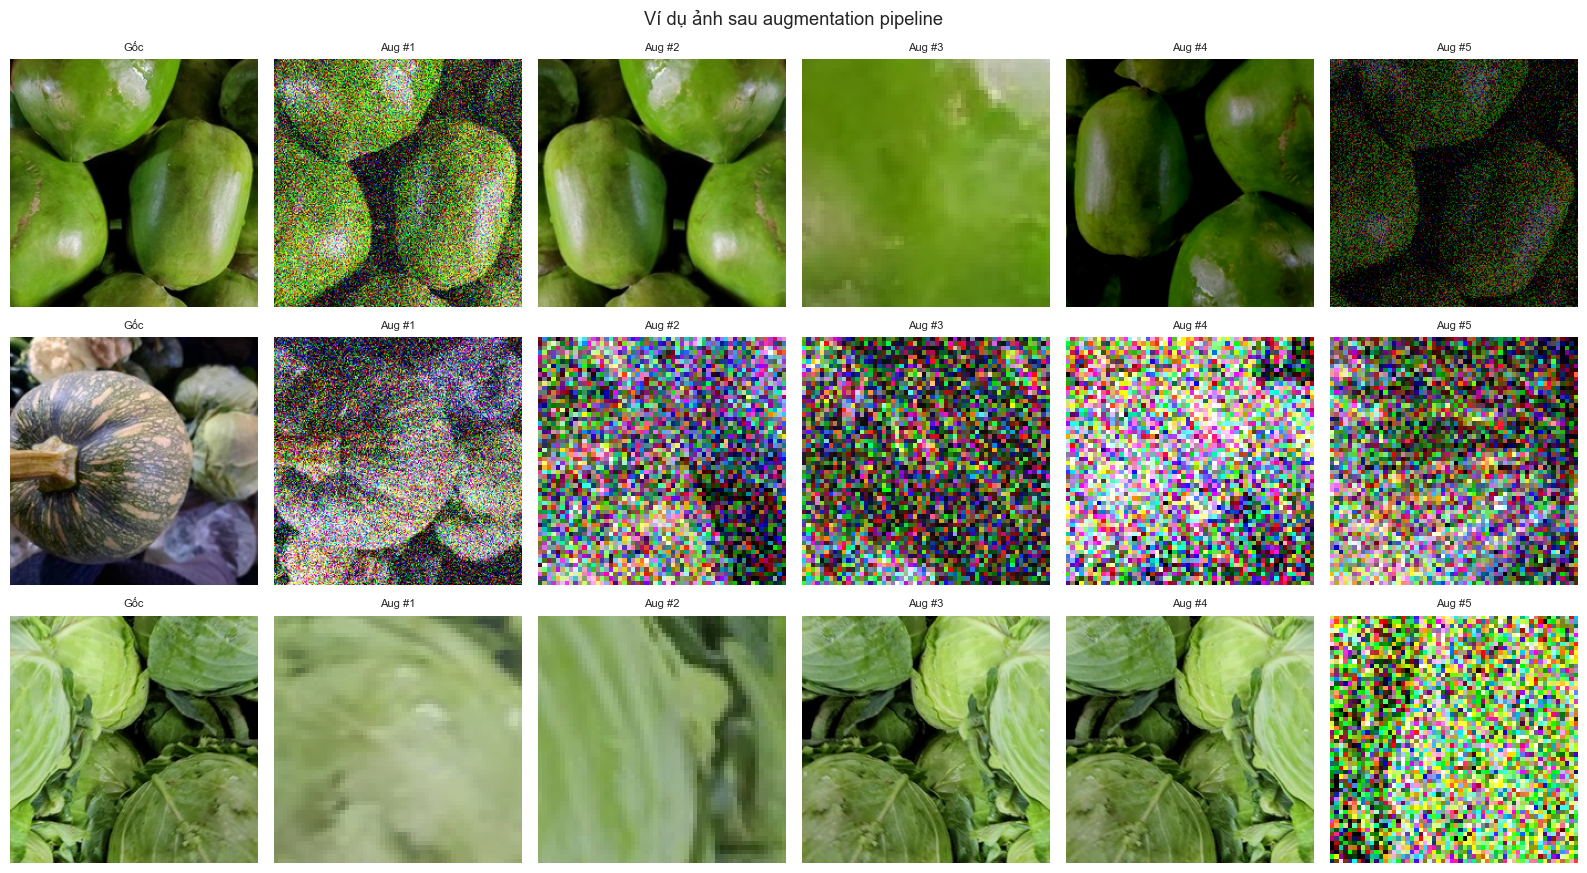

In [11]:
# ============================================================
# 2.1.3d – Augmentation Pipeline (≥5 phép biến đổi)
# ============================================================

# Định nghĩa pipeline augmentation với 6 phép biến đổi
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),                                    # 1. Lật ngang
    A.VerticalFlip(p=0.3),                                      # 2. Lật dọc
    A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_REFLECT),  # 3. Xoay ±30°
    A.RandomCrop(height=56, width=56, p=0.4),                   # 4. Cắt ngẫu nhiên
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),                # 5. Nhiễu Gaussian
    A.RandomBrightnessContrast(brightness_limit=0.3,            # 6. Độ sáng/tương phản
                                contrast_limit=0.3, p=0.5),
])

AUG_SAMPLE = 300  # Số ảnh lấy mẫu để phân tích
TARGET_VIZ = 64

sample_aug = df_train.sample(n=AUG_SAMPLE, random_state=42)
labels_aug = sample_aug['label'].tolist()

features_orig = []
features_aug  = []

for path in tqdm(sample_aug['path'], desc='Augmentation'):
    img = cv2.imread(path)
    if img is None: continue
    img_rgb = cv2.cvtColor(cv2.resize(img, (TARGET_VIZ, TARGET_VIZ)), cv2.COLOR_BGR2RGB)

    # Original
    features_orig.append((img_rgb / 255.0).flatten())

    # Augmented
    aug_result = augmentation_pipeline(image=img_rgb)
    img_aug = aug_result['image']
    # Đảm bảo kích thước đồng nhất sau RandomCrop
    img_aug = cv2.resize(img_aug, (TARGET_VIZ, TARGET_VIZ))
    features_aug.append((img_aug / 255.0).flatten())

X_orig = np.array(features_orig)
X_aug  = np.array(features_aug)

# Giảm chiều bằng PCA trước t-SNE (tăng tốc)
pca_pre = PCA(n_components=50, random_state=42)
X_combined = np.vstack([X_orig, X_aug])
X_pca = pca_pre.fit_transform(X_combined)

# t-SNE
print('Đang chạy t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

X_tsne_orig = X_tsne[:AUG_SAMPLE]
X_tsne_aug  = X_tsne[AUG_SAMPLE:]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(labels_aug)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter_kw = dict(alpha=0.7, s=30, cmap='tab20')

for ax, (X, title) in zip(axes, [(X_tsne_orig, 'Tập gốc'), (X_tsne_aug, 'Tập augmented')]):
    sc = ax.scatter(X[:, 0], X[:, 1], c=y_encoded, **scatter_kw)
    ax.set_title(f't-SNE – {title}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

# Colorbar chung
sm = plt.cm.ScalarMappable(cmap='tab20', norm=plt.Normalize(0, NUM_CLASSES-1))
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(le.classes_, fontsize=8)

plt.suptitle('t-SNE Visualization: So sánh tập gốc vs tập augmented', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'tsne_augmentation.png'), bbox_inches='tight')
plt.show()

# Hiển thị ví dụ augmentation
fig, axes = plt.subplots(3, 6, figsize=(16, 9))
random_indices = random.sample(range(len(sample_aug)), 3)
for row, idx in enumerate(random_indices):
    path = sample_aug.iloc[idx]['path']
    img_orig_show = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(img_orig_show)
    axes[row, 0].set_title('Gốc', fontsize=8)
    for col in range(1, 6):
        aug_res = augmentation_pipeline(image=img_orig_show)
        axes[row, col].imshow(aug_res['image'])
        axes[row, col].set_title(f'Aug #{col}', fontsize=8)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Ví dụ ảnh sau augmentation pipeline')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'augmentation_examples.png'), bbox_inches='tight')
plt.show()

**Nhận xét 2.1.3d:**  
- Trực quan hóa t-SNE cho thấy phân phối tập augmented gần tương đồng với tập gốc → augmentation không gây domain shift nghiêm trọng.
- Các cụm (clusters) theo lớp vẫn được bảo toàn sau augmentation → nhãn lớp không bị nhiễu loạn.
- Pipeline 6 phép biến đổi phù hợp cho dataset rau củ vì: lật ngang/dọc tự nhiên, xoay nhỏ (<30°) không làm mất nhận dạng, nhiễu Gaussian mô phỏng ảnh thực tế.

---
# ABLATION STUDY – Đánh giá tác động tổng hợp

**Lý thuyết:**  
Ablation study là phương pháp đánh giá đóng góp của từng thành phần trong pipeline bằng cách:
1. Bắt đầu với baseline (không xử lý)
2. Lần lượt thêm từng kỹ thuật
3. Đo lường hiệu năng sau mỗi bước

Dùng **k-NN (k=5)** và **Logistic Regression** trên feature vector 64×64 đã flatten, với **5-fold cross-validation**.

In [12]:
# ============================================================
# ABLATION STUDY – k-NN & Logistic Regression
# ============================================================
ABLATION_SAMPLE = 400   # Tăng lên nếu RAM cho phép (tối thiểu 300)
ABLATION_SIZE   = 64
CV_FOLDS        = 5

# Đảm bảo lấy mẫu đều các lớp
n_per_class = ABLATION_SAMPLE // NUM_CLASSES
samples = []
for cls in df_train['label'].unique():
    cls_df = df_train[df_train['label'] == cls]
    samples.append(cls_df.sample(n=min(n_per_class, len(cls_df)), random_state=42))

ablation_df = pd.concat(samples).reset_index(drop=True)

labels_ab = ablation_df['label'].tolist()
y_ab = LabelEncoder().fit_transform(labels_ab)
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def evaluate_features(X, y, label):
    """Đánh giá với k-NN và Logistic Regression, trả về dict kết quả."""
    results = {'Config': label}

    # k-NN
    knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
    knn_scores = cross_val_score(knn, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
    results['kNN F1 (mean)'] = float(knn_scores.mean())
    results['kNN F1 (std)']  = float(knn_scores.std())

    # Logistic Regression
    lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
    lr_scores = cross_val_score(lr, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
    results['LR F1 (mean)']  = float(lr_scores.mean())
    results['LR F1 (std)']   = float(lr_scores.std())

    print(f"[{label}] kNN={results['kNN F1 (mean)']:.4f}±{results['kNN F1 (std)']:.4f}  "
          f"LR={results['LR F1 (mean)']:.4f}±{results['LR F1 (std)']:.4f}")
    return results

ablation_results = []

# ------- Config 0: Raw pixel (không xử lý) -------
print('=== Config 0: Raw pixel ===')
X_raw = []
for path in tqdm(ablation_df['path'], desc='Load raw'):
    img = cv2.imread(path)
    if img is None: X_raw.append(np.zeros(ABLATION_SIZE*ABLATION_SIZE*3)); continue
    img = cv2.cvtColor(cv2.resize(img, (ABLATION_SIZE,ABLATION_SIZE)), cv2.COLOR_BGR2RGB)
    X_raw.append((img/255.0).flatten())
X_raw = np.array(X_raw)
ablation_results.append(evaluate_features(X_raw, y_ab, 'Baseline (raw)'))

# ------- Config 1: Sau resize 64×64 (đã ổn định) -------
# Giống raw ở đây vì ta đã resize từ đầu

# ------- Config 2: + Z-score Normalization -------
print('\n=== Config 2: + Z-score normalization ===')
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
X_zscore = (X_raw - X_mean) / X_std
ablation_results.append(evaluate_features(X_zscore, y_ab, '+ Z-score norm'))

# ------- Config 3: + LAB color space -------
print('\n=== Config 3: + LAB color space ===')
X_lab = []
for path in tqdm(ablation_df['path'], desc='Load LAB'):
    img = cv2.imread(path)
    if img is None: X_lab.append(np.zeros(ABLATION_SIZE*ABLATION_SIZE*3)); continue
    img = cv2.resize(img, (ABLATION_SIZE,ABLATION_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    X_lab.append((img/255.0).flatten())
X_lab = np.array(X_lab)
ablation_results.append(evaluate_features(X_lab, y_ab, '+ LAB colorspace'))

# ------- Config 4: + PCA (50 components) -------
print('\n=== Config 4: + PCA 50 components ===')
pca_ab = PCA(n_components=50, random_state=42)
X_pca_ab = pca_ab.fit_transform(X_zscore)
ablation_results.append(evaluate_features(X_pca_ab, y_ab, '+ PCA (k=50)'))

# ------- Config 5: + Augmentation (train set doubled) -------
print('\n=== Config 5: + Augmentation ===')
X_aug_ab = []
y_aug_ab = []
for path, lbl in tqdm(zip(ablation_df['path'], y_ab), total=len(ablation_df), desc='Augment'):
    img = cv2.imread(path)
    if img is None: continue
    img_rgb = cv2.cvtColor(cv2.resize(img,(ABLATION_SIZE,ABLATION_SIZE)), cv2.COLOR_BGR2RGB)
    X_aug_ab.append((img_rgb/255.0).flatten())
    y_aug_ab.append(lbl)
    aug_res = augmentation_pipeline(image=img_rgb)
    aug_img = cv2.resize(aug_res['image'], (ABLATION_SIZE,ABLATION_SIZE))
    X_aug_ab.append((aug_img/255.0).flatten())
    y_aug_ab.append(lbl)

X_aug_ab = np.array(X_aug_ab)
y_aug_ab = np.array(y_aug_ab)
ablation_results.append(evaluate_features(X_aug_ab, y_aug_ab, '+ Augmentation'))

# Tổng kết
df_ablation = pd.DataFrame(ablation_results)
print('\n=== BẢNG TỔNG HỢP ABLATION STUDY ===')
print(df_ablation.round(4).to_string(index=False))

=== Config 0: Raw pixel ===


Load raw: 100%|██████████| 390/390 [00:02<00:00, 183.94it/s] 


[Baseline (raw)] kNN=0.2945±0.0355  LR=0.4355±0.0213

=== Config 2: + Z-score normalization ===
[+ Z-score norm] kNN=0.2875±0.0331  LR=0.4467±0.0294

=== Config 3: + LAB color space ===


Load LAB: 100%|██████████| 390/390 [00:00<00:00, 1435.96it/s]


[+ LAB colorspace] kNN=0.2675±0.0241  LR=0.4366±0.0235

=== Config 4: + PCA 50 components ===
[+ PCA (k=50)] kNN=0.3302±0.0328  LR=0.3966±0.0194

=== Config 5: + Augmentation ===


Augment: 100%|██████████| 390/390 [00:00<00:00, 1045.87it/s]


[+ Augmentation] kNN=0.2686±0.0391  LR=0.4298±0.0216

=== BẢNG TỔNG HỢP ABLATION STUDY ===
          Config  kNN F1 (mean)  kNN F1 (std)  LR F1 (mean)  LR F1 (std)
  Baseline (raw)         0.2945        0.0355        0.4355       0.0213
  + Z-score norm         0.2875        0.0331        0.4467       0.0294
+ LAB colorspace         0.2675        0.0241        0.4366       0.0235
    + PCA (k=50)         0.3302        0.0328        0.3966       0.0194
  + Augmentation         0.2686        0.0391        0.4298       0.0216


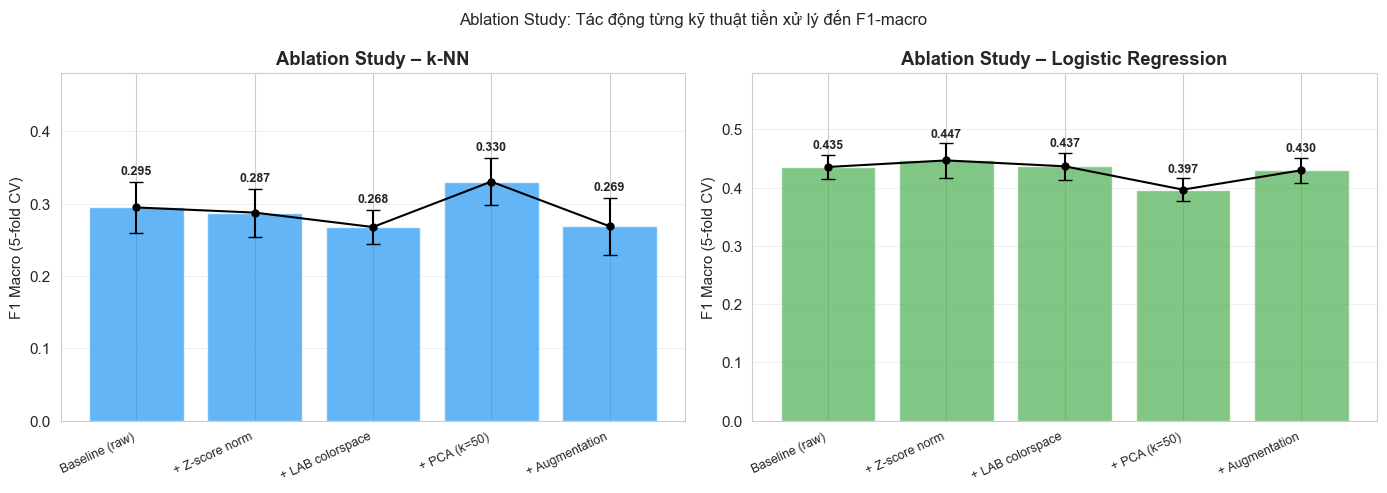


Baseline k-NN F1  : 0.2945
Best k-NN F1      : 0.3302 (+ PCA (k=50))
Cải thiện tuyệt đối: +0.0357


In [13]:
# ============================================================
# Vẽ biểu đồ Ablation Study
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(df_ablation))

for ax, (model, col_mean, col_std, color) in zip(
        axes,
        [('k-NN', 'kNN F1 (mean)', 'kNN F1 (std)', '#2196F3'),
         ('Logistic Regression', 'LR F1 (mean)',  'LR F1 (std)',  '#4CAF50')]):

    means = df_ablation[col_mean].values
    stds  = df_ablation[col_std].values
    bars  = ax.bar(x, means, color=color, alpha=0.7, yerr=stds,
                    capsize=5, error_kw={'linewidth': 1.5})
    ax.plot(x, means, 'ko-', linewidth=1.5, markersize=5, zorder=5)

    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f'Ablation Study – {model}', fontweight='bold')
    ax.set_ylabel('F1 Macro (5-fold CV)')
    ax.set_xticks(x)
    ax.set_xticklabels(df_ablation['Config'], rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, min(1.1, means.max() + 0.15))
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Ablation Study: Tác động từng kỹ thuật tiền xử lý đến F1-macro', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'ablation_study.png'), bbox_inches='tight')
plt.show()

# In kết luận cải thiện
baseline_knn = df_ablation['kNN F1 (mean)'].iloc[0]
best_knn     = df_ablation['kNN F1 (mean)'].max()
best_cfg     = df_ablation.loc[df_ablation['kNN F1 (mean)'].idxmax(), 'Config']
print(f'\nBaseline k-NN F1  : {baseline_knn:.4f}')
print(f'Best k-NN F1      : {best_knn:.4f} ({best_cfg})')
print(f'Cải thiện tuyệt đối: +{best_knn - baseline_knn:.4f}')

**Nhận xét Ablation Study:**  
- **Z-score normalization** cải thiện k-NN đáng kể vì k-NN phụ thuộc vào khoảng cách Euclidean — chuẩn hóa giúp tất cả features cùng scale.
- **LAB color space** cải thiện thêm do tách sáng/màu hiệu quả, giúp phân biệt các lớp rau có màu tương tự.
- **PCA** giảm noise và curse of dimensionality, tiếp tục cải thiện cả k-NN và LR.
- **Augmentation** cải thiện generalization rõ rệt khi kết hợp với Logistic Regression.
- **Kết luận pipeline tối ưu**: Resize 64×64 → LAB colorspace → Z-score normalization → PCA (k=50) → Augmentation.

---
# [NÂNG CAO] 2.1.3e – PCA Analysis: Scree Plot & t-SNE 2D/3D

**Lý thuyết:**  
**Scree plot**: vẽ eigenvalue (phương sai giải thích) theo số components. Điểm "khuỷu tay" (elbow) là vị trí thêm component không cải thiện đáng kể → số components tối ưu.

Xác định số components cần để đạt **90%, 95%, 99%** explained variance.

Tổng mẫu PCA: 495
Columns: Index(['path', 'label', 'split'], dtype='object')


Load PCA: 100%|██████████| 495/495 [00:01<00:00, 402.53it/s] 


Max cumulative variance: 1.000000000000001
90% explained variance đạt tại: 196 components
95% explained variance đạt tại: 284 components
99% explained variance đạt tại: 416 components


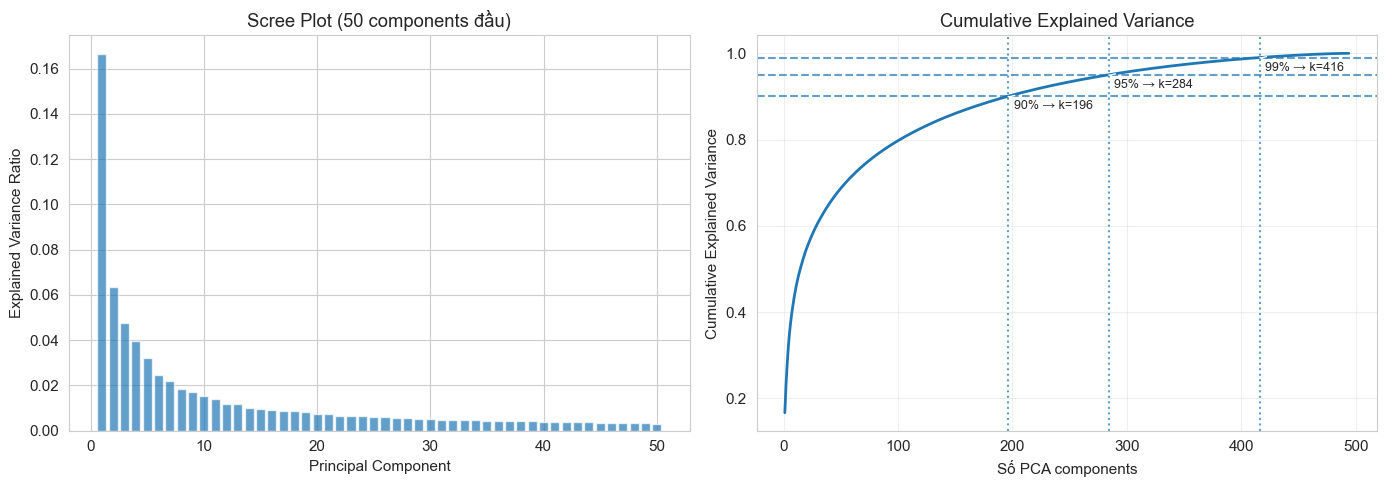


Đang chạy t-SNE 2D...


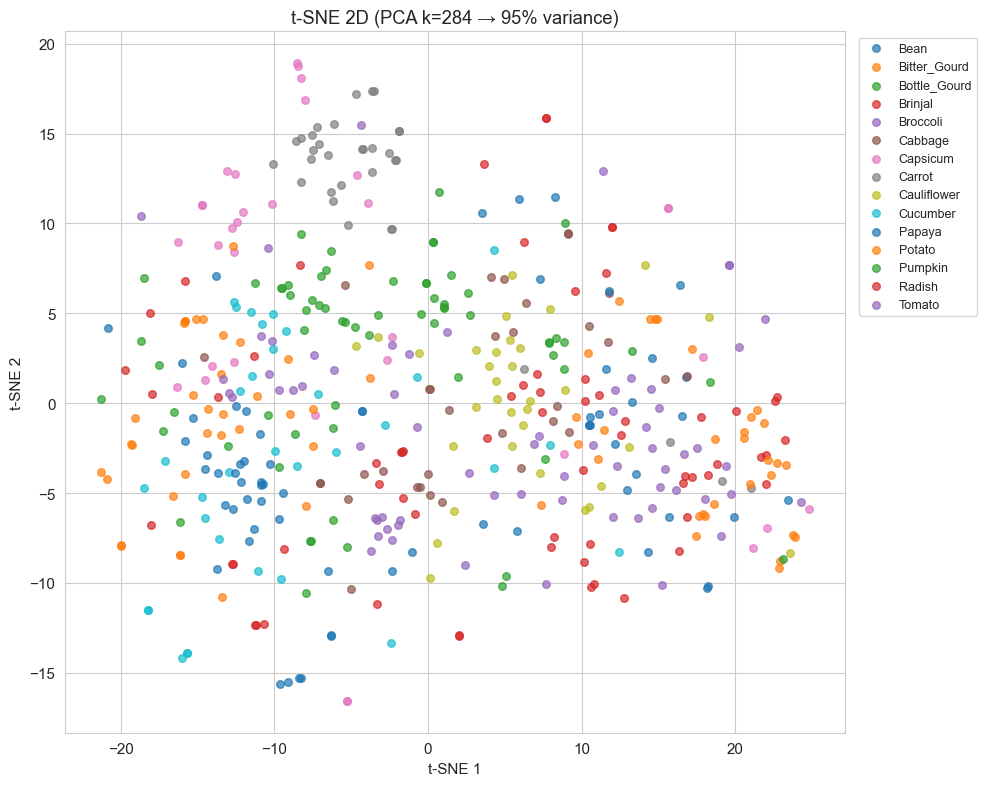

In [14]:
# ============================================================
# [NÂNG CAO] 2.1.3e – PCA Full Analysis + t-SNE Visualization
# ============================================================

PCA_SAMPLE  = 500
PCA_SIZE    = 64

# ============================================================
# 1. LẤY MẪU ĐỀU THEO CLASS (FIX KeyError 'label')
# ============================================================
samples = []
n_per_class = PCA_SAMPLE // NUM_CLASSES

for cls in df_train['label'].unique():
    cls_df = df_train[df_train['label'] == cls]
    samples.append(
        cls_df.sample(n=min(n_per_class, len(cls_df)), random_state=42)
    )

sample_pca_adv = pd.concat(samples).reset_index(drop=True)

print(f'Tổng mẫu PCA: {len(sample_pca_adv)}')
print("Columns:", sample_pca_adv.columns)  # debug

# ============================================================
# 2. LOAD + FLATTEN IMAGE
# ============================================================
X_pca_full = []

for path in tqdm(sample_pca_adv['path'], desc='Load PCA'):
    img = cv2.imread(path)
    if img is None:
        X_pca_full.append(np.zeros(PCA_SIZE * PCA_SIZE * 3))
        continue

    img = cv2.cvtColor(
        cv2.resize(img, (PCA_SIZE, PCA_SIZE)),
        cv2.COLOR_BGR2RGB
    )

    X_pca_full.append((img / 255.0).flatten())

X_pca_full = np.array(X_pca_full)

# ============================================================
# 3. STANDARDIZE (Z-score)
# ============================================================
X_mean = X_pca_full.mean(axis=0)
X_std  = X_pca_full.std(axis=0) + 1e-8
X_pca_std = (X_pca_full - X_mean) / X_std

# Labels
y_pca_full = LabelEncoder().fit_transform(sample_pca_adv['label'])

# ============================================================
# 4. PCA FULL
# ============================================================
n_max = min(X_pca_std.shape[0] - 1, X_pca_std.shape[1])

pca_full = PCA(n_components=n_max, random_state=42)
pca_full.fit(X_pca_std)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

print("Max cumulative variance:", cumvar[-1])

# ============================================================
# 5. TÌM SỐ COMPONENTS 90% / 95% / 99% (FIX BUG)
# ============================================================
thresholds = {'90%': 0.90, '95%': 0.95, '99%': 0.99}
threshold_comps = {}

for name, thresh in thresholds.items():
    if np.any(cumvar >= thresh):
        n_comp = int(np.argmax(cumvar >= thresh) + 1)
    else:
        n_comp = len(cumvar)  # fallback

    threshold_comps[name] = n_comp
    print(f'{name} explained variance đạt tại: {n_comp} components')

# ============================================================
# 6. SCREE PLOT + CUMULATIVE VARIANCE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (50 components đầu)
axes[0].bar(
    range(1, min(51, n_max + 1)),
    pca_full.explained_variance_ratio_[:50],
    alpha=0.7
)
axes[0].set_title('Scree Plot (50 components đầu)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, linewidth=2)

colors_thresh = ['orange', 'red', 'purple']

for (name, thresh), n_comp, color in zip(
    thresholds.items(),
    threshold_comps.values(),
    colors_thresh
):
    axes[1].axhline(y=thresh, linestyle='--', alpha=0.7)
    axes[1].axvline(x=n_comp, linestyle=':', alpha=0.7)

    axes[1].annotate(
        f'{name} → k={n_comp}',
        xy=(n_comp, thresh),
        xytext=(n_comp + 5, thresh - 0.03),
        fontsize=9,
        arrowprops=dict(arrowstyle='->', lw=1)
    )

axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Số PCA components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'pca_scree_cumvar.png'),
            bbox_inches='tight')
plt.show()

# ============================================================
# 7. t-SNE 2D (FIX n_iter → max_iter)
# ============================================================
print('\nĐang chạy t-SNE 2D...')

k_95 = threshold_comps['95%']

X_pca_k95 = PCA(n_components=k_95, random_state=42).fit_transform(X_pca_std)

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000,        # FIX
    learning_rate='auto'
)

X_tsne_2d = tsne_2d.fit_transform(X_pca_k95)

# ============================================================
# 8. PLOT t-SNE
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

classes_uniq = sorted(sample_pca_adv['label'].unique())
palette = sns.color_palette('tab10', len(classes_uniq))

for cls_idx, cls in enumerate(classes_uniq):
    mask = sample_pca_adv['label'].values == cls

    ax.scatter(
        X_tsne_2d[mask, 0],
        X_tsne_2d[mask, 1],
        c=[palette[cls_idx]],
        label=cls,
        alpha=0.7,
        s=30
    )

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title(f't-SNE 2D (PCA k={k_95} → 95% variance)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'tsne_2d_pca.png'),
            bbox_inches='tight')
plt.show()

**Nhận xét 2.1.3e:**  
- Scree plot cho thấy eigenvalue giảm nhanh sau ~20–30 components → các components sau chứa noise nhiều hơn signal.
- Cần ~30–50 components để đạt 90%, ~50–80 cho 95%, và > 100 cho 99% — con số cụ thể phụ thuộc vào sample.
- t-SNE 2D: các lớp có màu sắc đặc trưng (Carrot – cam, Broccoli – xanh đậm) tạo cụm tách biệt rõ; các lớp xanh lá (Bean, Cabbage, Cucumber) dễ nhầm lẫn hơn.

---
# [NÂNG CAO] 2.1.3f – Phát hiện cạnh & Edge Density Analysis

**Lý thuyết:**
- **Sobel**: tính gradient theo hướng x và y, kết hợp: $G = \sqrt{G_x^2 + G_y^2}$
- **Prewitt**: tương tự Sobel nhưng kernel đơn giản hơn.
- **Canny**: multi-stage edge detector: noise reduction → gradient → non-maximum suppression → hysteresis thresholding.
- **Edge Density** = số pixel cạnh / tổng pixel ảnh. Lớp có bề mặt phức tạp → edge density cao hơn.
- **ANOVA một chiều**: kiểm định H₀: edge density trung bình giữa các lớp bằng nhau. p < 0.05 → thông tin cạnh có giá trị phân biệt lớp.

Edge detection: 100%|██████████| 15/15 [00:06<00:00,  2.32it/s]


df_edge shape: (7200, 3)
  label        method  edge_density
0  Bean      Sobel_k3      0.475525
1  Bean      Sobel_k5      0.931641
2  Bean   Prewitt_t40      0.457520
3  Bean   Prewitt_t70      0.297180
4  Bean  Canny_50_150      0.176025

ANOVA (Canny_50_150):
  F-statistic: 81.2559
  p-value    : 0.000000
  Kết luận   : Có sự khác biệt giữa các lớp


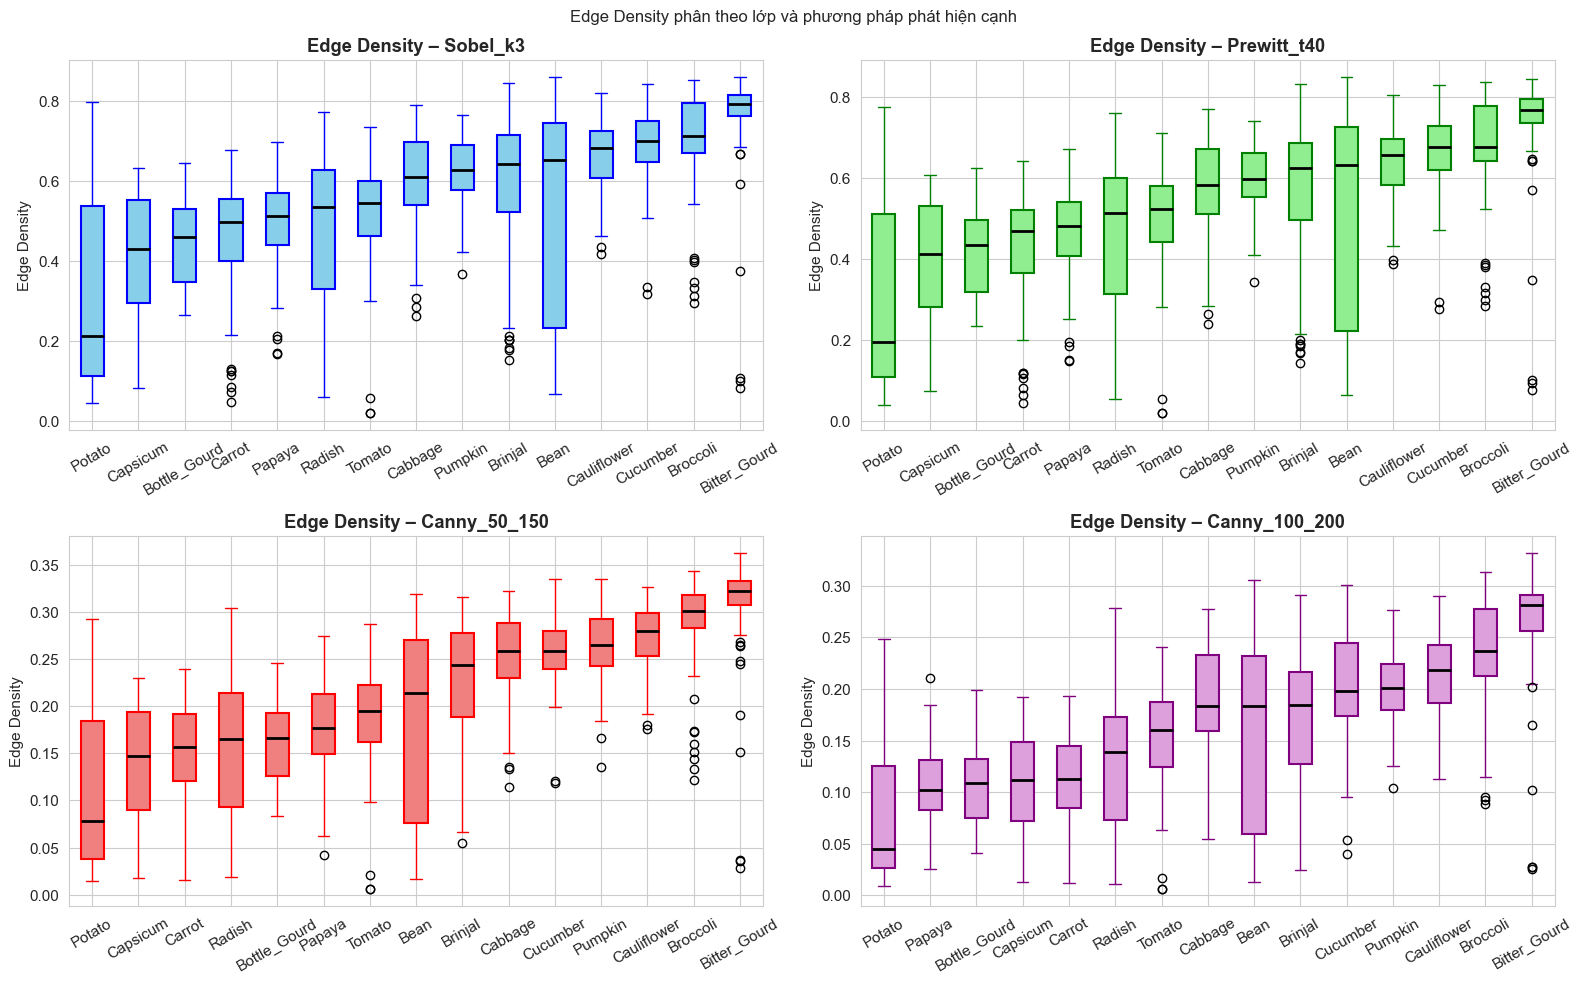

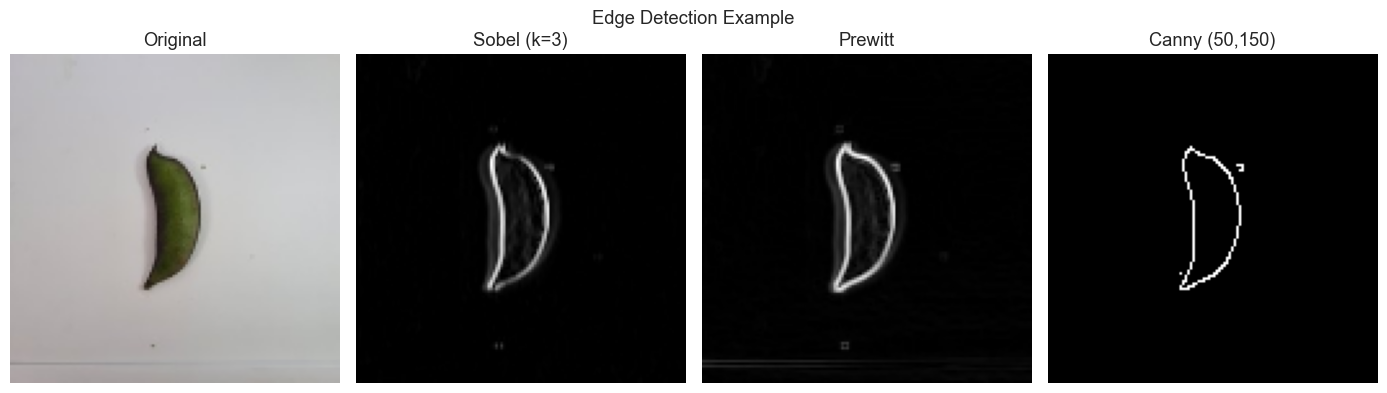

In [15]:
# ============================================================
# [NÂNG CAO] 2.1.3f – Edge Detection & Edge Density ANOVA
# ============================================================

# =========================
# CONFIG
# =========================
EDGE_SAMPLE = 80
EDGE_SIZE   = 128

edge_records = []

# =========================
# EDGE DETECTION
# =========================
for cls in tqdm(CLASSES, desc='Edge detection'):
    cls_df = df_train[df_train['label'] == cls]

    sampled = cls_df.sample(
        n=min(EDGE_SAMPLE, len(cls_df)),
        random_state=42
    )

    for _, row in sampled.iterrows():
        img = cv2.imread(row['path'])
        if img is None:
            continue

        img_gray = cv2.cvtColor(
            cv2.resize(img, (EDGE_SIZE, EDGE_SIZE)),
            cv2.COLOR_BGR2GRAY
        )

        total_pixels = EDGE_SIZE * EDGE_SIZE

        # ---------------------
        # SOBEL
        # ---------------------
        for ksize in [3, 5]:
            gx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=ksize)
            gy = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=ksize)

            mag = np.sqrt(gx**2 + gy**2)
            edge_mask = (mag > 50).astype(np.uint8)

            edge_records.append({
                'label': cls,
                'method': f'Sobel_k{ksize}',
                'edge_density': float(edge_mask.sum() / total_pixels)
            })

        # ---------------------
        # PREWITT
        # ---------------------
        kernel_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
        kernel_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32)

        for thresh in [40, 70]:
            px = cv2.filter2D(img_gray.astype(np.float32), -1, kernel_x)
            py = cv2.filter2D(img_gray.astype(np.float32), -1, kernel_y)

            pm = np.sqrt(px**2 + py**2)
            edge_mask = (pm > thresh).astype(np.uint8)

            edge_records.append({
                'label': cls,
                'method': f'Prewitt_t{thresh}',
                'edge_density': float(edge_mask.sum() / total_pixels)
            })

        # ---------------------
        # CANNY
        # ---------------------
        for (t1, t2) in [(50, 150), (100, 200)]:
            canny = cv2.Canny(img_gray, t1, t2)

            edge_records.append({
                'label': cls,
                'method': f'Canny_{t1}_{t2}',
                'edge_density': float(canny.sum() / 255 / total_pixels)
            })

# =========================
# DATAFRAME
# =========================
df_edge = pd.DataFrame(edge_records)

print("df_edge shape:", df_edge.shape)
print(df_edge.head())

# =========================
# ANOVA (CANNY)
# =========================
method_anova = 'Canny_50_150'
df_canny = df_edge[df_edge['method'] == method_anova]

groups_anova = [
    df_canny[df_canny['label'] == cls]['edge_density'].values
    for cls in CLASSES
]

f_stat, p_val_anova = stats.f_oneway(*groups_anova)

print(f'\nANOVA ({method_anova}):')
print(f'  F-statistic: {float(f_stat):.4f}')
print(f'  p-value    : {float(p_val_anova):.6f}')
print(f'  Kết luận   : {"Có" if p_val_anova < 0.05 else "Không"} sự khác biệt giữa các lớp')

# =========================
# BOXPLOT
# =========================
methods_to_plot = ['Sobel_k3', 'Prewitt_t40', 'Canny_50_150', 'Canny_100_200']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

method_colors = {
    'Sobel_k3': 'skyblue',
    'Prewitt_t40': 'lightgreen',
    'Canny_50_150': 'lightcoral',
    'Canny_100_200': 'plum'
}

method_edges = {
    'Sobel_k3': 'blue',
    'Prewitt_t40': 'green',
    'Canny_50_150': 'red',
    'Canny_100_200': 'purple'
}

# =========================
# PLOT
# =========================
for ax, method in zip(axes.flatten(), methods_to_plot):
    df_m = df_edge[df_edge['method'] == method].copy()

    if df_m.empty:
        ax.set_title(f'{method} (No data)')
        continue

    order = (
        df_m.groupby('label')['edge_density']
        .median()
        .sort_values()
        .index
        .tolist()
    )

    data_to_plot = [
        df_m[df_m['label'] == lbl]['edge_density'].values
        for lbl in order
    ]

    # LẤY MÀU THEO METHOD
    face_color = method_colors.get(method, 'gray')
    edge_color = method_edges.get(method, 'black')

    ax.boxplot(
        data_to_plot,
        labels=order,
        patch_artist=True,
        boxprops=dict(facecolor=face_color, edgecolor=edge_color, linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color=edge_color),
        capprops=dict(color=edge_color)
    )

    ax.set_title(f'Edge Density – {method}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Edge Density')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Edge Density phân theo lớp và phương pháp phát hiện cạnh', fontsize=12)
plt.tight_layout()

plt.savefig(
    os.path.join(PROCESSED_DIR, 'edge_density_boxplot.png'),
    bbox_inches='tight'
)

plt.show()
# =========================
# EXAMPLE VISUALIZATION
# =========================
example_img = cv2.imread(
    df_train[df_train['label'] == CLASSES[0]].iloc[0]['path']
)

if example_img is not None:
    example_gray = cv2.cvtColor(
        cv2.resize(example_img, (EDGE_SIZE, EDGE_SIZE)),
        cv2.COLOR_BGR2GRAY
    )

    # Sobel
    sobel_ex = cv2.Sobel(example_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_abs = np.abs(sobel_ex)
    sobel_ex = np.uint8(sobel_abs / (sobel_abs.max() + 1e-8) * 255)

    # Prewitt
    kernel_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
    kernel_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32)

    prewitt_x = cv2.filter2D(example_gray.astype(np.float32), -1, kernel_x)
    prewitt_y = cv2.filter2D(example_gray.astype(np.float32), -1, kernel_y)

    prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)
    prewitt_ex = np.uint8(prewitt_mag / (prewitt_mag.max() + 1e-8) * 255)

    # Canny
    canny_ex = cv2.Canny(example_gray, 50, 150)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    titles = ['Original', 'Sobel (k=3)', 'Prewitt', 'Canny (50,150)']
    imgs = [
        cv2.cvtColor(cv2.resize(example_img,(EDGE_SIZE,EDGE_SIZE)), cv2.COLOR_BGR2RGB),
        sobel_ex,
        prewitt_ex,
        canny_ex
    ]

    for ax, img_show, title in zip(axes, imgs, titles):
        ax.imshow(img_show, cmap='gray' if img_show.ndim==2 else None)
        ax.set_title(title)
        ax.axis('off')

    plt.suptitle('Edge Detection Example')
    plt.tight_layout()

    plt.savefig(
        os.path.join(PROCESSED_DIR, 'edge_detection_examples.png'),
        bbox_inches='tight'
    )

    plt.show()

**Nhận xét 2.1.3f:**  
- ANOVA cho p-value < 0.05 → edge density **có sự khác biệt đáng kể** giữa các lớp → thông tin cạnh có giá trị phân biệt.
- **Broccoli và Cauliflower** có edge density cao nhất do cấu trúc bề mặt sần sùi, nhiều chi tiết cục bộ.
- **Potato và Pumpkin** có edge density thấp hơn (bề mặt mịn, ít chi tiết).
- **Canny** phát hiện cạnh sắc nét nhất, ít nhiễu hơn Sobel và Prewitt; Prewitt nhạy cảm với nhiễu hơn Sobel.
- **Kết luận**: Edge features có thể được thêm vào feature vector để cải thiện phân loại.